# F1 Win Probability Model
Trains a baseline classifier to predict `won` from the cleaned lap-level dataset.

Key decisions (see `docs/08_eda_findings.md` for the reasoning):
- `points`, `positionOrder`, `statusId` excluded — data leakage (they describe the outcome)
- Train/test split is **by race, time-based** — not random — to avoid leaking laps from the same race across the split, and to mirror real-world use (train on past races, evaluate on future ones)

## 1. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve)
import joblib
import os

df = pd.read_csv('../data/processed/cleaned_dataset.csv', low_memory=False)
print('Shape:', df.shape)

Shape: (320274, 66)


## 2. Select features
Explicitly exclude: identifiers (not predictive, just labels), leakage columns (describe the outcome), and text/object columns not yet encoded (kept simple for this baseline).

In [2]:
leakage_cols = ['points', 'positionOrder', 'statusId']
identifier_cols = ['raceId', 'driverId', 'driver_number', 'session_key', 'meeting_key']
text_cols = df.select_dtypes(include=['object']).columns.tolist()
label_col = 'won'

exclude = set(leakage_cols + identifier_cols + text_cols + [label_col])
feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype != 'object']

print(f'{len(feature_cols)} features selected:')
print(feature_cols)

43 features selected:
['year', 'round', 'lap', 'position', 'grid', 'milliseconds', 'cum_time_ms', 'gap_to_leader_ms', 'pit_stop_this_lap', 'cumulative_pit_stops', 'laps_since_last_pit', 'pit_duration_ms', 'total_laps', 'race_progress', 'position_vs_grid', 'position_change', 'rolling_lap_time_ms', 'pace_delta_to_fastest_ms', 'gap_to_leader_s', 'gap_per_lap_covered_s', 'tire_age_ratio', 'gap_to_ahead_ms', 'drs_zone_proxy', 'pit_window_proxy', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'lap_duration', 'st_speed', 'pit_stop_duration_s', 'stint_number', 'tyre_age_at_stint_start', 'pressure', 'track_temperature', 'rainfall', 'wind_speed', 'wind_direction', 'humidity', 'air_temperature', 'has_openf1_telemetry', 'anomalous_lap_time']


In [3]:
# gap_to_leader_ms and gap_to_leader_s are the same value in different units —
# keep only one to avoid artificially splitting this feature's importance in two.
# Keeping the seconds version since it's more human-readable for the dashboard.
if 'gap_to_leader_ms' in feature_cols:
    feature_cols.remove('gap_to_leader_ms')

print(f'{len(feature_cols)} features selected (after removing duplicate):')
print(feature_cols)

42 features selected (after removing duplicate):
['year', 'round', 'lap', 'position', 'grid', 'milliseconds', 'cum_time_ms', 'pit_stop_this_lap', 'cumulative_pit_stops', 'laps_since_last_pit', 'pit_duration_ms', 'total_laps', 'race_progress', 'position_vs_grid', 'position_change', 'rolling_lap_time_ms', 'pace_delta_to_fastest_ms', 'gap_to_leader_s', 'gap_per_lap_covered_s', 'tire_age_ratio', 'gap_to_ahead_ms', 'drs_zone_proxy', 'pit_window_proxy', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'lap_duration', 'st_speed', 'pit_stop_duration_s', 'stint_number', 'tyre_age_at_stint_start', 'pressure', 'track_temperature', 'rainfall', 'wind_speed', 'wind_direction', 'humidity', 'air_temperature', 'has_openf1_telemetry', 'anomalous_lap_time']


## 3. Handle remaining missing values in features
Tree-based models (Random Forest) can't handle NaN directly in scikit-learn. Fill numeric gaps with a clear out-of-range sentinel value rather than the mean/median, so the model can distinguish "missing" from a real low value if that pattern matters (e.g. OpenF1-only columns being NaN for all non-2023 rows).

In [4]:
X = df[feature_cols].copy()
y = df[label_col].copy()

print('Missing values per feature (top 10):')
print(X.isnull().sum().sort_values(ascending=False).head(10))

X = X.fillna(-999)

Missing values per feature (top 10):
i1_speed             300424
st_speed             298848
wind_direction       298228
wind_speed           298228
pressure             298228
humidity             298228
rainfall             298228
track_temperature    298228
air_temperature      298228
duration_sector_1    296972
dtype: int64


## 4. Time-based train/test split by race
Train on earlier seasons, test on the most recent ones — no race appears in both sets.

In [5]:
print('Year range:', df['year'].min(), '-', df['year'].max())
print(df['year'].value_counts().sort_index())

Year range: 2011 - 2024
year
2011    24008
2012    25343
2013    22779
2014    21021
2015    19855
2016    24513
2017    20307
2018    22246
2019    23625
2020    18400
2021    23688
2022    23529
2023    24386
2024    26574
Name: count, dtype: int64


In [6]:
# Use the most recent full season as the test set; everything before it is training.
TEST_YEAR = df['year'].max()

train_mask = df['year'] < TEST_YEAR
test_mask = df['year'] == TEST_YEAR

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Train: {X_train.shape[0]} rows ({y_train.mean()*100:.2f}% won)')
print(f'Test:  {X_test.shape[0]} rows ({y_test.mean()*100:.2f}% won)')

Train: 293700 rows (5.34% won)
Test:  26574 rows (5.43% won)


## 5. Train baseline model
Random Forest handles non-linear feature interactions well and gives interpretable feature importance — a good baseline before trying anything more complex like XGBoost. `class_weight='balanced'` compensates for the 5.35% win rate so the model doesn't just learn to always predict 'not won'.

In [7]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 6. Evaluate
Accuracy is NOT used as the headline metric (see EDA findings — class imbalance makes it misleading). ROC-AUC, precision, and recall are used instead.

In [8]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'ROC-AUC:   {auc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 score:  {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not won', 'Won']))

ROC-AUC:   0.9769
Precision: 0.4905
Recall:    0.8615
F1 score:  0.6251

              precision    recall  f1-score   support

     Not won       0.99      0.95      0.97     25130
         Won       0.49      0.86      0.63      1444

    accuracy                           0.94     26574
   macro avg       0.74      0.91      0.80     26574
weighted avg       0.96      0.94      0.95     26574



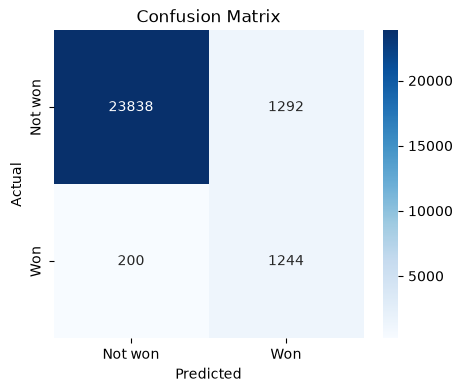

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not won', 'Won'], yticklabels=['Not won', 'Won'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

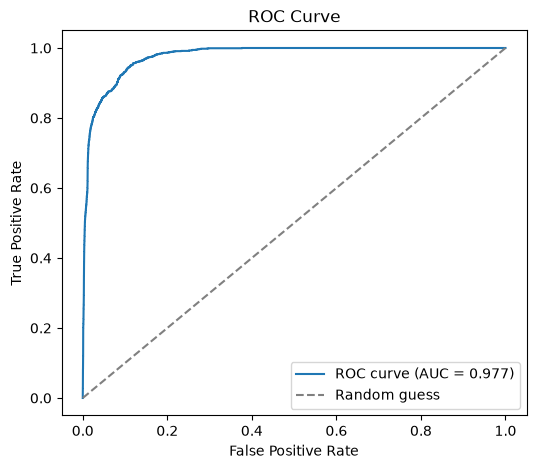

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 7. Feature importance — this is your Objective 1 answer
Unlike the linear correlation check in EDA, Random Forest importance captures non-linear effects and interactions between features.

position                    0.208349
gap_per_lap_covered_s       0.176957
gap_to_leader_s             0.159562
grid                        0.141126
gap_to_ahead_ms             0.118084
pace_delta_to_fastest_ms    0.051263
drs_zone_proxy              0.044453
position_vs_grid            0.019609
cum_time_ms                 0.008076
race_progress               0.007803
tire_age_ratio              0.007359
rolling_lap_time_ms         0.006809
milliseconds                0.006656
total_laps                  0.006620
laps_since_last_pit         0.005780
round                       0.005597
lap                         0.005425
year                        0.005278
position_change             0.003656
cumulative_pit_stops        0.002894
dtype: float64


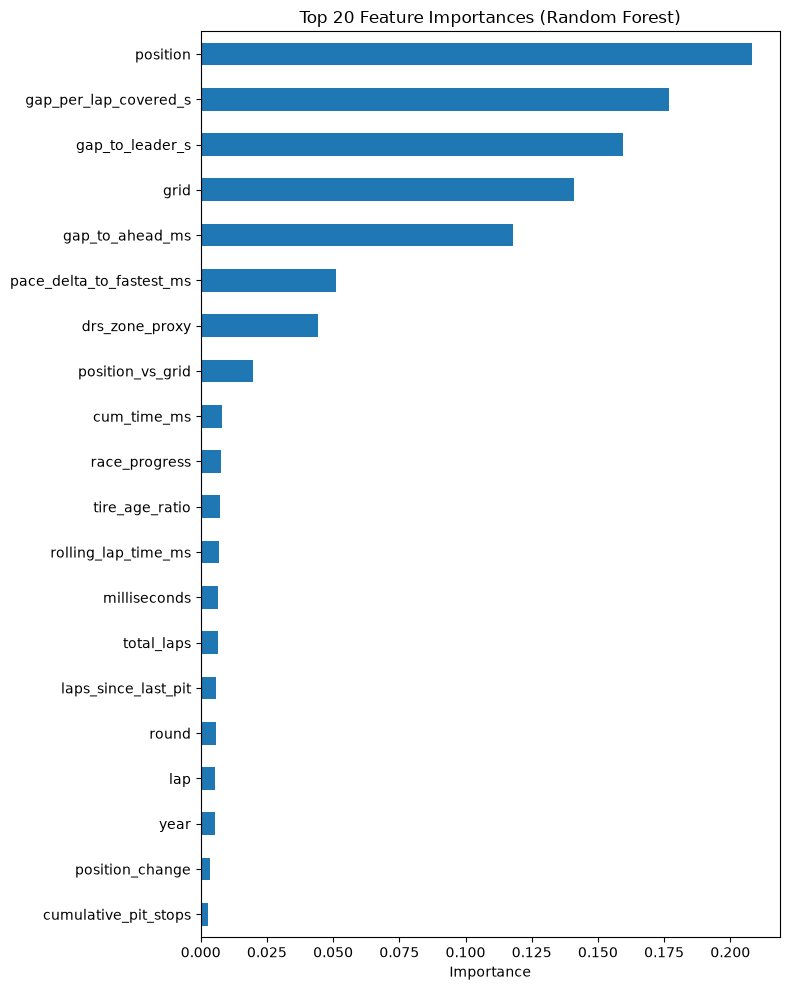

In [11]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(20))

plt.figure(figsize=(8, 10))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Save the model

In [12]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/win_probability_model.pkl')
joblib.dump(feature_cols, '../models/feature_columns.pkl')
print('Saved -> models/win_probability_model.pkl')
print('Saved -> models/feature_columns.pkl')

Saved -> models/win_probability_model.pkl
Saved -> models/feature_columns.pkl


## 9. Calibration check

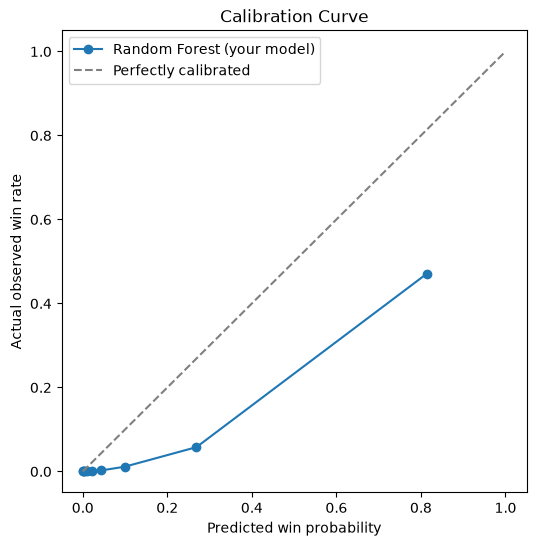

Predicted vs Actual, by bucket:
  Predicted ~0.000  ->  Actual ~0.000
  Predicted ~0.001  ->  Actual ~0.000
  Predicted ~0.002  ->  Actual ~0.000
  Predicted ~0.005  ->  Actual ~0.000
  Predicted ~0.011  ->  Actual ~0.000
  Predicted ~0.021  ->  Actual ~0.000
  Predicted ~0.044  ->  Actual ~0.003
  Predicted ~0.099  ->  Actual ~0.011
  Predicted ~0.269  ->  Actual ~0.058
  Predicted ~0.814  ->  Actual ~0.471


In [13]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest (your model)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted win probability')
plt.ylabel('Actual observed win rate')
plt.title('Calibration Curve')
plt.legend()
plt.show()

print("Predicted vs Actual, by bucket:")
for p, t in zip(prob_pred, prob_true):
    print(f"  Predicted ~{p:.3f}  ->  Actual ~{t:.3f}")

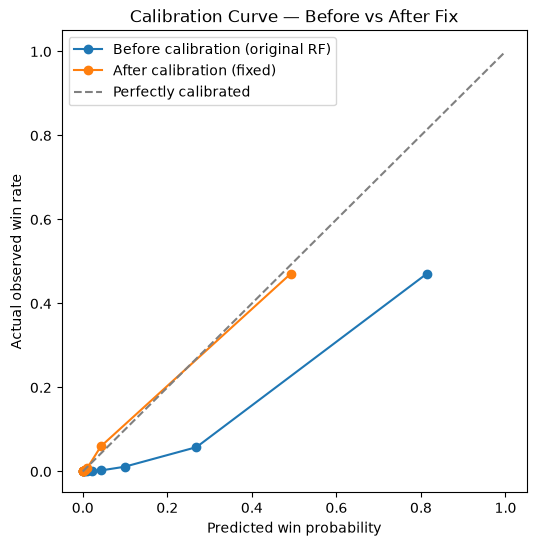

Brier score before: 0.0423
Brier score after:  0.0226
ROC-AUC before: 0.9769
ROC-AUC after:  0.9774


In [14]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score
# method='isotonic' fits a flexible correction curve — well-suited here since your
# miscalibration pattern isn't a simple straight-line shift (see the curve shape above)
calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# Re-check calibration after the fix
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calibrated_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Before calibration (original RF)')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='After calibration (fixed)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted win probability')
plt.ylabel('Actual observed win rate')
plt.title('Calibration Curve — Before vs After Fix')
plt.legend()
plt.show()

print(f"Brier score before: {brier_score_loss(y_test, y_pred_proba):.4f}")
print(f"Brier score after:  {brier_score_loss(y_test, calibrated_proba):.4f}")
print(f"ROC-AUC before: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"ROC-AUC after:  {roc_auc_score(y_test, calibrated_proba):.4f}")

### After Calibration 

In [15]:
import joblib

joblib.dump(calibrated_model, '../models/win_probability_model_calibrated.pkl')
print("Saved -> models/win_probability_model_calibrated.pkl")

Saved -> models/win_probability_model_calibrated.pkl


## 10. Model comparison

### Logistic Regression 

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
logreg_pred = logreg.predict(X_test_scaled)

print("Logistic Regression:")
print("ROC-AUC:  ", roc_auc_score(y_test, logreg_proba))
print("Precision:", precision_score(y_test, logreg_pred))
print("Recall:   ", recall_score(y_test, logreg_pred))
print("Brier:    ", brier_score_loss(y_test, logreg_proba))

Logistic Regression:
ROC-AUC:   0.966085221116124
Precision: 0.28094059405940597
Recall:    0.943213296398892
Brier:     0.08926047301586043


### XGBoost

In [17]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

print("XGBoost:")
print("ROC-AUC:  ", roc_auc_score(y_test, xgb_proba))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:   ", recall_score(y_test, xgb_pred))
print("Brier:    ", brier_score_loss(y_test, xgb_proba))

XGBoost:
ROC-AUC:   0.96633979759544
Precision: 0.5262230057293962
Recall:    0.8268698060941828
Brier:     0.03817141428589821


## Comparison Table 

In [18]:
results = pd.DataFrame({
    'Model': ['Random Forest (calibrated)', 'Logistic Regression', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, calibrated_proba),
        roc_auc_score(y_test, logreg_proba),
        roc_auc_score(y_test, xgb_proba),
    ],
    'Precision': [
        precision_score(y_test, calibrated_model.predict(X_test)),
        precision_score(y_test, logreg_pred),
        precision_score(y_test, xgb_pred),
    ],
    'Recall': [
        recall_score(y_test, calibrated_model.predict(X_test)),
        recall_score(y_test, logreg_pred),
        recall_score(y_test, xgb_pred),
    ],
    'Brier Score': [
        brier_score_loss(y_test, calibrated_proba),
        brier_score_loss(y_test, logreg_proba),
        brier_score_loss(y_test, xgb_proba),
    ],
})
print(results.round(4))

                        Model  ROC-AUC  Precision  Recall  Brier Score
0  Random Forest (calibrated)   0.9774     0.7615  0.6856       0.0226
1         Logistic Regression   0.9661     0.2809  0.9432       0.0893
2                     XGBoost   0.9663     0.5262  0.8269       0.0382


## Calibrate Logistic Regression and XGBoost too:

In [19]:
from sklearn.calibration import CalibratedClassifierCV

# Logistic Regression is usually already well-calibrated by nature (it directly
# optimizes a probability-based loss function), but let's verify rather than assume
calibrated_logreg = CalibratedClassifierCV(logreg, method='isotonic', cv=5)
calibrated_logreg.fit(X_train_scaled, y_train)
calibrated_logreg_proba = calibrated_logreg.predict_proba(X_test_scaled)[:, 1]
calibrated_logreg_pred = calibrated_logreg.predict(X_test_scaled)

# XGBoost, like Random Forest, often benefits from calibration
calibrated_xgb = CalibratedClassifierCV(xgb_model, method='isotonic', cv=5)
calibrated_xgb.fit(X_train, y_train)
calibrated_xgb_proba = calibrated_xgb.predict_proba(X_test)[:, 1]
calibrated_xgb_pred = calibrated_xgb.predict(X_test)

print("Calibration complete for all three models.")

Calibration complete for all three models.


## The fully fair, all-calibrated comparison table:

In [20]:
results_calibrated = pd.DataFrame({
    'Model': ['Random Forest (calibrated)', 'Logistic Regression (calibrated)', 'XGBoost (calibrated)'],
    'ROC-AUC': [
        roc_auc_score(y_test, calibrated_proba),
        roc_auc_score(y_test, calibrated_logreg_proba),
        roc_auc_score(y_test, calibrated_xgb_proba),
    ],
    'Precision': [
        precision_score(y_test, calibrated_model.predict(X_test)),
        precision_score(y_test, calibrated_logreg_pred),
        precision_score(y_test, calibrated_xgb_pred),
    ],
    'Recall': [
        recall_score(y_test, calibrated_model.predict(X_test)),
        recall_score(y_test, calibrated_logreg_pred),
        recall_score(y_test, calibrated_xgb_pred),
    ],
    'Brier Score': [
        brier_score_loss(y_test, calibrated_proba),
        brier_score_loss(y_test, calibrated_logreg_proba),
        brier_score_loss(y_test, calibrated_xgb_proba),
    ],
})
print(results_calibrated.round(4))

                              Model  ROC-AUC  Precision  Recall  Brier Score
0        Random Forest (calibrated)   0.9774     0.7615  0.6856       0.0226
1  Logistic Regression (calibrated)   0.9662     0.6798  0.7188       0.0263
2              XGBoost (calibrated)   0.9625     0.7639  0.6163       0.0243


## 11. Walk-forward validation
Testing across multiple years to confirm strong performance isn't a lucky single split.

In [21]:
walk_forward_years = [2022, 2023, 2024]  # each year tested using only prior years as training
wf_results = []

for test_year in walk_forward_years:
    train_mask_wf = df['year'] < test_year
    test_mask_wf = df['year'] == test_year

    X_train_wf, X_test_wf = X[train_mask_wf], X[test_mask_wf]
    y_train_wf, y_test_wf = y[train_mask_wf], y[test_mask_wf]

    model_wf = RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    model_wf.fit(X_train_wf, y_train_wf)

    calibrated_wf = CalibratedClassifierCV(model_wf, method='isotonic', cv=5)
    calibrated_wf.fit(X_train_wf, y_train_wf)
    proba_wf = calibrated_wf.predict_proba(X_test_wf)[:, 1]
    pred_wf = calibrated_wf.predict(X_test_wf)

    wf_results.append({
        'Test Year': test_year,
        'Train Rows': len(X_train_wf),
        'Test Rows': len(X_test_wf),
        'ROC-AUC': roc_auc_score(y_test_wf, proba_wf),
        'Precision': precision_score(y_test_wf, pred_wf),
        'Recall': recall_score(y_test_wf, pred_wf),
        'Brier Score': brier_score_loss(y_test_wf, proba_wf),
    })

wf_df = pd.DataFrame(wf_results)
print(wf_df.round(4))

   Test Year  Train Rows  Test Rows  ROC-AUC  Precision  Recall  Brier Score
0       2022      245785      23529   0.9776     0.7283  0.6298       0.0242
1       2023      269314      24386   0.9917     0.8826  0.8340       0.0142
2       2024      293700      26574   0.9774     0.7615  0.6856       0.0226


In [22]:
season_2023 = df[df['year'] == 2023]
print("2023 win rate by constructor (top 5):")
print(season_2023[season_2023['won']==1]['constructor_name'].value_counts().head(5))
print()
print("Overall 2023 win concentration - top constructor's share of all wins:")
win_counts_2023 = season_2023[season_2023['won']==1]['constructor_name'].value_counts()
print(f"{win_counts_2023.index[0]}: {win_counts_2023.iloc[0]} of {win_counts_2023.sum()} total wins "
      f"({win_counts_2023.iloc[0]/win_counts_2023.sum()*100:.0f}%)")

2023 win rate by constructor (top 5):
constructor_name
Red Bull    1263
Ferrari       62
Name: count, dtype: int64

Overall 2023 win concentration - top constructor's share of all wins:
Red Bull: 1263 of 1325 total wins (95%)


## 12. Rebuild feature list without the duplicate gap column

In [23]:

if 'gap_to_leader_ms' in feature_cols:
    feature_cols_v2 = [c for c in feature_cols if c != 'gap_to_leader_ms']
else:
    feature_cols_v2 = feature_cols.copy()

X_v2 = df[feature_cols_v2].fillna(-999)
X_train_v2, X_test_v2 = X_v2[train_mask], X_v2[test_mask]

# Train fresh
model_v2 = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
model_v2.fit(X_train_v2, y_train)

# Calibrate
calibrated_v2 = CalibratedClassifierCV(model_v2, method='isotonic', cv=5)
calibrated_v2.fit(X_train_v2, y_train)
proba_v2 = calibrated_v2.predict_proba(X_test_v2)[:, 1]
pred_v2 = calibrated_v2.predict(X_test_v2)

print("=== Performance after removing duplicate gap column ===")
print("ROC-AUC:  ", roc_auc_score(y_test, proba_v2))
print("Precision:", precision_score(y_test, pred_v2))
print("Recall:   ", recall_score(y_test, pred_v2))
print("Brier:    ", brier_score_loss(y_test, proba_v2))

print("\n=== Top 15 feature importances ===")
importances_v2 = pd.Series(model_v2.feature_importances_, index=feature_cols_v2).sort_values(ascending=False)
print(importances_v2.head(15))

=== Performance after removing duplicate gap column ===
ROC-AUC:   0.9773822521778718
Precision: 0.7615384615384615
Recall:    0.685595567867036
Brier:     0.022588206401246664

=== Top 15 feature importances ===
position                    0.208349
gap_per_lap_covered_s       0.176957
gap_to_leader_s             0.159562
grid                        0.141126
gap_to_ahead_ms             0.118084
pace_delta_to_fastest_ms    0.051263
drs_zone_proxy              0.044453
position_vs_grid            0.019609
cum_time_ms                 0.008076
race_progress               0.007803
tire_age_ratio              0.007359
rolling_lap_time_ms         0.006809
milliseconds                0.006656
total_laps                  0.006620
laps_since_last_pit         0.005780
dtype: float64


In [24]:
joblib.dump(calibrated_v2, '../models/win_probability_model_calibrated.pkl')
joblib.dump(feature_cols_v2, '../models/feature_columns.pkl')
print("Saved final model and feature list.")

Saved final model and feature list.


## 13. Investigation: driver-relative pace feature (tire degradation vs fuel/track evolution)

The original `pace_delta_to_fastest_ms` compares each lap to the fastest lap set by
ANYONE in the field — this conflates car/team performance with genuine tire wear.
Testing whether comparing each driver to their OWN fresh-tire baseline pace reveals
a clearer tire-degradation signal.

In [25]:
# Build a unique ID for each individual stint (one driver, one race, one pit-stop segment)
df['stint_key'] = (
    df['raceId'].astype(str) + '_' +
    df['driverId'].astype(str) + '_' +
    df['cumulative_pit_stops'].astype(str)
)

# For each stint, find this driver's own median lap time during their first 3 laps
# on fresh tires (excluding the red-flag/safety-car anomalous laps we flagged earlier)
fresh_laps = df[(df['laps_since_last_pit'] <= 2) & (df['anomalous_lap_time'] == 0)]
stint_baseline = fresh_laps.groupby('stint_key')['milliseconds'].median()

df['stint_baseline_pace_ms'] = df['stint_key'].map(stint_baseline)

# The new feature: how much slower is this lap vs THIS driver's own fresh-tire pace
# in THIS stint? Positive = degrading, near 0 = still fast.
df['pace_vs_own_baseline_ms'] = df['milliseconds'] - df['stint_baseline_pace_ms']

print("New feature created. Sample:")
print(df[['raceId','driverId','lap','laps_since_last_pit','milliseconds',
          'stint_baseline_pace_ms','pace_vs_own_baseline_ms']].head(10))

New feature created. Sample:
   raceId  driverId  lap  laps_since_last_pit  milliseconds  \
0     841        20    1                    0         98109   
1     841         1    1                    0        100573   
2     841        17    1                    0        101467   
3     841       808    1                    0        102835   
4     841        13    1                    0        104196   
5     841        18    1                    0        104722   
6     841         3    1                    0        105340   
7     841       155    1                    0        105896   
8     841         4    1                    0        106144   
9     841       814    1                    0        107562   

   stint_baseline_pace_ms  pace_vs_own_baseline_ms  
0                 93006.0                   5103.0  
1                 93774.0                   6799.0  
2                 93725.0                   7742.0  
3                 94363.0                   8472.0  
4           

In [26]:
degradation_check = df.groupby('laps_since_last_pit')['pace_vs_own_baseline_ms'].median()
print(degradation_check.head(25))

laps_since_last_pit
0     14187.0
1         0.0
2      -152.0
3      -457.0
4      -524.5
5      -585.0
6      -615.5
7      -633.0
8      -611.0
9      -611.0
10     -623.0
11     -646.0
12     -677.0
13     -683.0
14     -731.5
15     -791.0
16     -809.0
17     -866.0
18     -911.5
19     -928.0
20     -995.0
21    -1069.0
22    -1141.0
23    -1156.0
24    -1181.0
Name: pace_vs_own_baseline_ms, dtype: float64


In [27]:
print("Old feature (pace_delta_to_fastest_ms) correlation with won:",
      df['pace_delta_to_fastest_ms'].corr(df['won']))
print("New feature (pace_vs_own_baseline_ms) correlation with won:",
      df['pace_vs_own_baseline_ms'].corr(df['won']))
print()
print("Old feature correlation with laps_since_last_pit (tire age):",
      df['pace_delta_to_fastest_ms'].corr(df['laps_since_last_pit']))
print("New feature correlation with laps_since_last_pit (tire age):",
      df['pace_vs_own_baseline_ms'].corr(df['laps_since_last_pit']))

Old feature (pace_delta_to_fastest_ms) correlation with won: -0.006007412890576376
New feature (pace_vs_own_baseline_ms) correlation with won: -0.004547880049911783

Old feature correlation with laps_since_last_pit (tire age): -0.04272034624842941
New feature correlation with laps_since_last_pit (tire age): -0.05756703032883148


## 14. SHAP values — explaining individual predictions

Global feature importance (Section 7) shows what matters on AVERAGE across the whole
dataset. SHAP breaks down a SINGLE prediction into per-feature contributions, enabling
the dashboard to explain "why is THIS driver's probability what it is" rather than
only "what matters in general."

Note: SHAP is computed on the underlying Random Forest (model_v2), not the calibrated
wrapper — TreeExplainer works directly on tree-based models and is very fast; the
calibration layer is a separate probability correction applied on top afterward.

In [28]:
import shap

explainer = shap.TreeExplainer(model_v2)

# Compute SHAP values for a sample of the test set (full test set would be slow —
# a few hundred rows is plenty to validate this works and inspect results)
sample_idx = X_test_v2.sample(200, random_state=1).index
X_sample = X_test_v2.loc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("SHAP values computed.")
print("Shape:", np.array(shap_values).shape)

c:\Users\Lenovo\Desktop\F1 Sport\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values computed.
Shape: (200, 42, 2)


In [29]:
# shap_values has shape (rows, features, classes) — we want class index 1 ("won")
shap_values_won = shap_values[:, :, 1]

print("Shape after selecting the 'won' class:", shap_values_won.shape)

# Quick sanity check: average absolute SHAP value per feature should roughly
# match the global feature_importances_ ranking from Section 7
shap_importance = pd.Series(
    np.abs(shap_values_won).mean(axis=0), index=feature_cols_v2
).sort_values(ascending=False)

print("\nTop 10 features by mean |SHAP value| (sanity check vs Section 7 ranking):")
print(shap_importance.head(10))

Shape after selecting the 'won' class: (200, 42)

Top 10 features by mean |SHAP value| (sanity check vs Section 7 ranking):
position                    0.104313
gap_to_leader_s             0.082729
grid                        0.080837
gap_per_lap_covered_s       0.067733
gap_to_ahead_ms             0.063151
pace_delta_to_fastest_ms    0.027090
drs_zone_proxy              0.020981
tire_age_ratio              0.010765
position_vs_grid            0.009672
race_progress               0.008234
dtype: float64


In [30]:
def explain_prediction(row_index_in_sample):
    """Show a plain-language breakdown of one specific prediction."""
    row_features = X_sample.iloc[row_index_in_sample]
    row_shap = shap_values_won[row_index_in_sample]

    explanation = pd.Series(row_shap, index=feature_cols_v2).sort_values(key=abs, ascending=False)

    print(f"Base rate (average win probability across all drivers): {explainer.expected_value[1]*100:.2f}%")
    print(f"\nTop factors for this specific prediction:")
    for feature, value in explanation.head(8).items():
        direction = "increases" if value > 0 else "decreases"
        print(f"  {feature:30s} {direction} win probability by {abs(value)*100:.2f} points "
              f"(actual value: {row_features[feature]:.2f})")

# Try it on the first row in our sample
explain_prediction(0)

Base rate (average win probability across all drivers): 50.00%

Top factors for this specific prediction:
  position                       decreases win probability by 17.20 points (actual value: 18.00)
  gap_per_lap_covered_s          decreases win probability by 9.57 points (actual value: 1.56)
  grid                           increases win probability by 9.07 points (actual value: 0.00)
  gap_to_ahead_ms                decreases win probability by 6.72 points (actual value: 715.00)
  gap_to_leader_s                decreases win probability by 6.42 points (actual value: 17.12)
  position_vs_grid               decreases win probability by 5.66 points (actual value: -18.00)
  pace_delta_to_fastest_ms       decreases win probability by 4.13 points (actual value: 2089.00)
  drs_zone_proxy                 increases win probability by 1.32 points (actual value: 1.00)


In [31]:
# Compare raw model_v2 output vs the calibrated version, for the same row
raw_proba = model_v2.predict_proba(X_sample.iloc[[0]])[0][1]
calibrated_proba_row = calibrated_v2.predict_proba(X_sample.iloc[[0]])[0][1]

print(f"Raw model_v2 probability:        {raw_proba*100:.2f}%")
print(f"Calibrated probability:          {calibrated_proba_row*100:.2f}%")
print(f"SHAP base rate + sum of SHAP values: {(explainer.expected_value[1] + shap_values_won[0].sum())*100:.2f}%")

Raw model_v2 probability:        7.41%
Calibrated probability:          0.66%
SHAP base rate + sum of SHAP values: 7.41%


In [32]:
def explain_prediction(row_index_in_sample):
    """Show a plain-language breakdown of one specific prediction.
    Headline probability = calibrated (trustworthy). SHAP = directional reasoning
    from the underlying raw model, not a literal decomposition of the calibrated number."""
    row_features = X_sample.iloc[[row_index_in_sample]]
    row_shap = shap_values_won[row_index_in_sample]

    calibrated_prob = calibrated_v2.predict_proba(row_features)[0][1]

    explanation = pd.Series(row_shap, index=feature_cols_v2).sort_values(key=abs, ascending=False)

    print(f"Win probability (calibrated, trustworthy): {calibrated_prob*100:.2f}%")
    print(f"\nKey factors driving this prediction (direction and relative strength,")
    print(f"from the underlying model's reasoning):")
    for feature, value in explanation.head(8).items():
        direction = "pushes probability UP" if value > 0 else "pushes probability DOWN"
        print(f"  {feature:30s} {direction:25s} (actual value: {row_features[feature].values[0]:.2f})")

explain_prediction(0)

Win probability (calibrated, trustworthy): 0.66%

Key factors driving this prediction (direction and relative strength,
from the underlying model's reasoning):
  position                       pushes probability DOWN   (actual value: 18.00)
  gap_per_lap_covered_s          pushes probability DOWN   (actual value: 1.56)
  grid                           pushes probability UP     (actual value: 0.00)
  gap_to_ahead_ms                pushes probability DOWN   (actual value: 715.00)
  gap_to_leader_s                pushes probability DOWN   (actual value: 17.12)
  position_vs_grid               pushes probability DOWN   (actual value: -18.00)
  pace_delta_to_fastest_ms       pushes probability DOWN   (actual value: 2089.00)
  drs_zone_proxy                 pushes probability UP     (actual value: 1.00)


In [33]:
import joblib

# Calibrated model — used for ALL probability predictions (trustworthy numbers)
joblib.dump(calibrated_v2, '../models/win_probability_model_calibrated.pkl')

# Raw model — kept separately, used ONLY for feature_importances_ (CalibratedClassifierCV
# wraps the real model in cross-validated folds and doesn't expose this attribute directly)
joblib.dump(model_v2, '../models/win_probability_model_raw.pkl')

# Updated 42-feature list (without the duplicate gap_to_leader_ms)
joblib.dump(feature_cols_v2, '../models/feature_columns.pkl')

print("Saved all three files.")

Saved all three files.


In [35]:
from sklearn.frozen import FrozenEstimator

# Three-way, time-based split: train the model on older years, calibrate it (once,
# not 5x) on a separate held-out year, then test on the final year.
CALIBRATION_YEAR = 2023
TEST_YEAR = 2024

train_mask_v3 = df['year'] < CALIBRATION_YEAR
calib_mask_v3 = df['year'] == CALIBRATION_YEAR
test_mask_v3 = df['year'] == TEST_YEAR

X_train_v3, y_train_v3 = X[train_mask_v3], y[train_mask_v3]
X_calib_v3, y_calib_v3 = X[calib_mask_v3], y[calib_mask_v3]
X_test_v3, y_test_v3 = X[test_mask_v3], y[test_mask_v3]

# Fit the Random Forest ONCE, on the training years only
model_v3 = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
model_v3.fit(X_train_v3, y_train_v3)

# Wrap the already-fitted model with FrozenEstimator, telling CalibratedClassifierCV
# "don't retrain this — just calibrate it once, using the calibration-year data"
# (this replaces the older, now-deprecated cv='prefit' syntax)
calibrated_v3 = CalibratedClassifierCV(FrozenEstimator(model_v3), method='isotonic')
calibrated_v3.fit(X_calib_v3, y_calib_v3)

proba_v3 = calibrated_v3.predict_proba(X_test_v3)[:, 1]
pred_v3 = calibrated_v3.predict(X_test_v3)

print("=== Faster calibration (FrozenEstimator) — performance check ===")
print("ROC-AUC:  ", roc_auc_score(y_test_v3, proba_v3))
print("Precision:", precision_score(y_test_v3, pred_v3))
print("Recall:   ", recall_score(y_test_v3, pred_v3))
print("Brier:    ", brier_score_loss(y_test_v3, proba_v3))

=== Faster calibration (FrozenEstimator) — performance check ===
ROC-AUC:   0.9747401324745671
Precision: 0.7652905198776758
Recall:    0.693213296398892
Brier:     0.02357030178460844


In [36]:
import time

start = time.time()
for _ in range(50):
    calibrated_v3.predict_proba(X_test_v3.iloc[[0]])
print(f"New (FrozenEstimator) avg time per prediction: {(time.time()-start)/50*1000:.2f} ms")

start = time.time()
for _ in range(50):
    calibrated_v2.predict_proba(X_test_v2.iloc[[0]])
print(f"Old (cv=5) avg time per prediction: {(time.time()-start)/50*1000:.2f} ms")

New (FrozenEstimator) avg time per prediction: 53.24 ms
Old (cv=5) avg time per prediction: 291.37 ms


In [37]:
joblib.dump(calibrated_v3, '../models/win_probability_model_calibrated.pkl')
joblib.dump(model_v3, '../models/win_probability_model_raw.pkl')
joblib.dump(feature_cols_v2, '../models/feature_columns.pkl')
print("Saved final, fast, calibrated model.")

Saved final, fast, calibrated model.
